Sinal 1 (Pulso Finito)  -> Energia Total: 19.0000 | Potência Média final: 0.9500
Sinal 2 (Exponencial)   -> Energia Total: 1.9608 | Potência Média final: 0.0980
Sinal 3 (Senoide Pura)  -> Energia Total: 10.0000 | Potência Média final: 0.5000


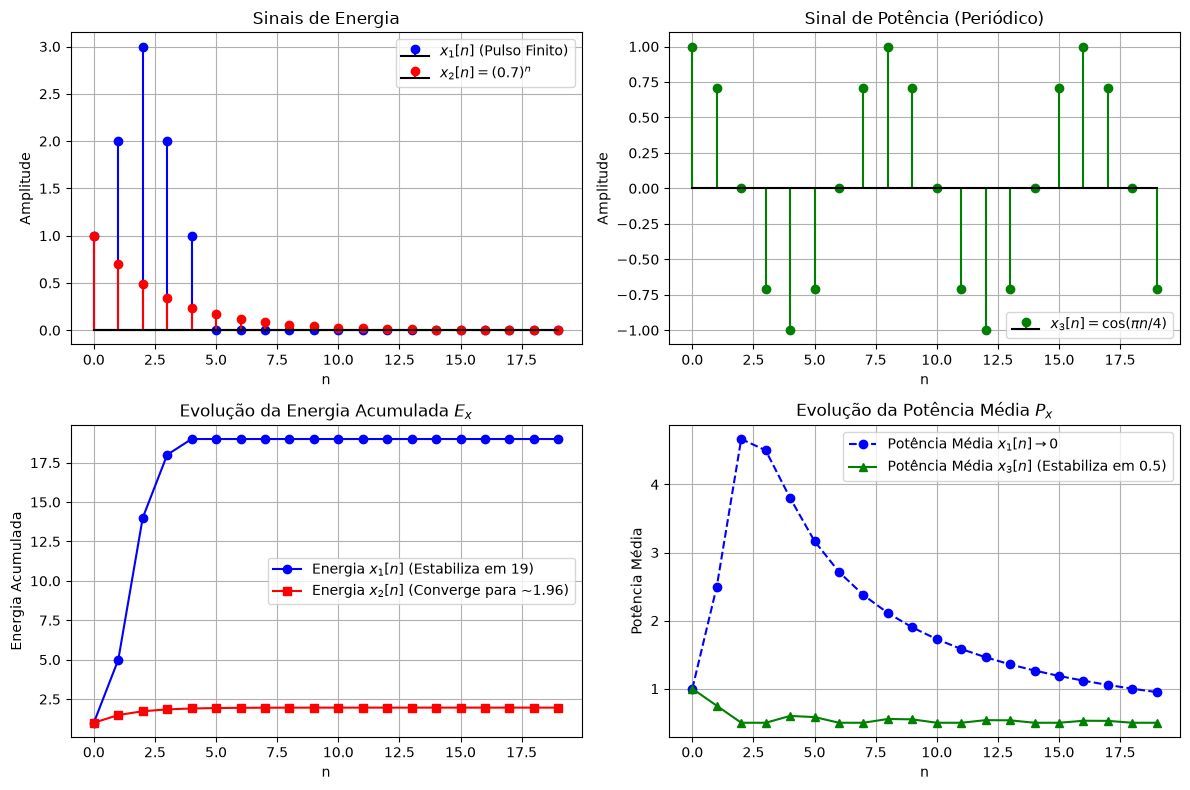

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Domínio temporal discreto (n = 0 a 19)
n = np.arange(0, 20)

# 1. Definição correta dos 3 sinais
x1 = np.array([1, 2, 3, 2, 1] + [0] * (len(n) - 5))  # Pulso Finito
x2 = (0.7) ** n  # Exponencial Causal (Energia)
x3 = np.cos(np.pi * n / 4)  # Senoide Periódica (Potência)

# 2. Cálculo da Energia Acumulada e Potência Média Acumulada
E1_acum = np.cumsum(np.abs(x1) ** 2)
E2_acum = np.cumsum(np.abs(x2) ** 2)
E3_acum = np.cumsum(np.abs(x3) ** 2)

P1_acum = E1_acum / (n + 1)
P2_acum = E2_acum / (n + 1)
P3_acum = E3_acum / (n + 1)

# 3. Impressão dos resultados numéricos no console
print(
    f"Sinal 1 (Pulso Finito)  -> Energia Total: {E1_acum[-1]:.4f} | Potência Média final: {P1_acum[-1]:.4f}"
)
print(
    f"Sinal 2 (Exponencial)   -> Energia Total: {E2_acum[-1]:.4f} | Potência Média final: {P2_acum[-1]:.4f}"
)
print(
    f"Sinal 3 (Senoide Pura)  -> Energia Total: {E3_acum[-1]:.4f} | Potência Média final: {P3_acum[-1]:.4f}"
)

# 4. Plotagem dos Gráficos
plt.figure(figsize=(12, 8))

# Subplot 1: Sinais no Tempo Discreto
plt.subplot(2, 2, 1)
plt.stem(
    n,
    x1,
    linefmt="b-",
    markerfmt="bo",
    basefmt="k-",
    label=r"$x_1[n]$ (Pulso Finito)",
)
plt.stem(
    n,
    x2,
    linefmt="r-",
    markerfmt="ro",
    basefmt="k-",
    label=r"$x_2[n] = (0.7)^n$",
)
plt.title("Sinais de Energia")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.stem(
    n,
    x3,
    linefmt="g-",
    markerfmt="go",
    basefmt="k-",
    label=r"$x_3[n] = \cos(\pi n / 4)$",
)
plt.title("Sinal de Potência (Periódico)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# Subplot 2: Evolução de Energia e Potência Acumuladas
plt.subplot(2, 2, 3)
plt.plot(n, E1_acum, "b-o", label=r"Energia $x_1[n]$ (Estabiliza em 19)")
plt.plot(n, E2_acum, "r-s", label=r"Energia $x_2[n]$ (Converge para ~1.96)")
plt.title(r"Evolução da Energia Acumulada $E_x$")
plt.xlabel("n")
plt.ylabel("Energia Acumulada")
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(n, P1_acum, "b--o", label=r"Potência Média $x_1[n] \to 0$")
plt.plot(
    n, P3_acum, "g-^", label=r"Potência Média $x_3[n]$ (Estabiliza em 0.5)"
)
plt.title(r"Evolução da Potência Média $P_x$")
plt.xlabel("n")
plt.ylabel("Potência Média")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()